In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
sales = pd.read_csv("../../../Data/sales.csv")
products = pd.read_csv("../../../Data/products.csv")
stores = pd.read_csv("../../../Data/stores.csv")
category = pd.read_csv("../../../Data/category.csv")
warranty = pd.read_csv("../../../Data/warranty.csv")

Plot a histogram with a KDE overlay of price from products.csv, and describe where most of Apple's catalog sits.

In [4]:
products.columns

Index(['product_id', 'product_name', 'category_id', 'launch_date', 'price'], dtype='object')

In [6]:
category.columns

Index(['category_id', 'category_name'], dtype='object')

In [7]:
category["category_name"].unique()

array(['Laptop', 'Audio', 'Tablet', 'Smartphone', 'Wearable',
       'Streaming Device', 'Desktop', 'Subscription Service',
       'Smart Speaker', 'Accessory'], dtype=object)

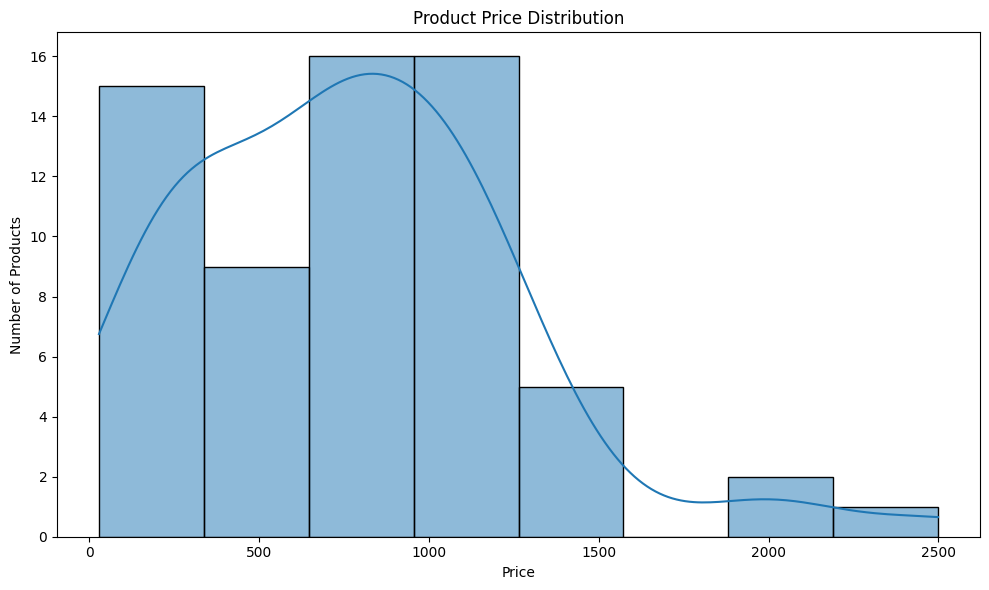

In [11]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=products,
    x="price",
    kde=True
)

plt.title("Product Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

Join sales.csv and products.csv to derive a per-transaction revenue value, then plot its distribution and describe its skew.

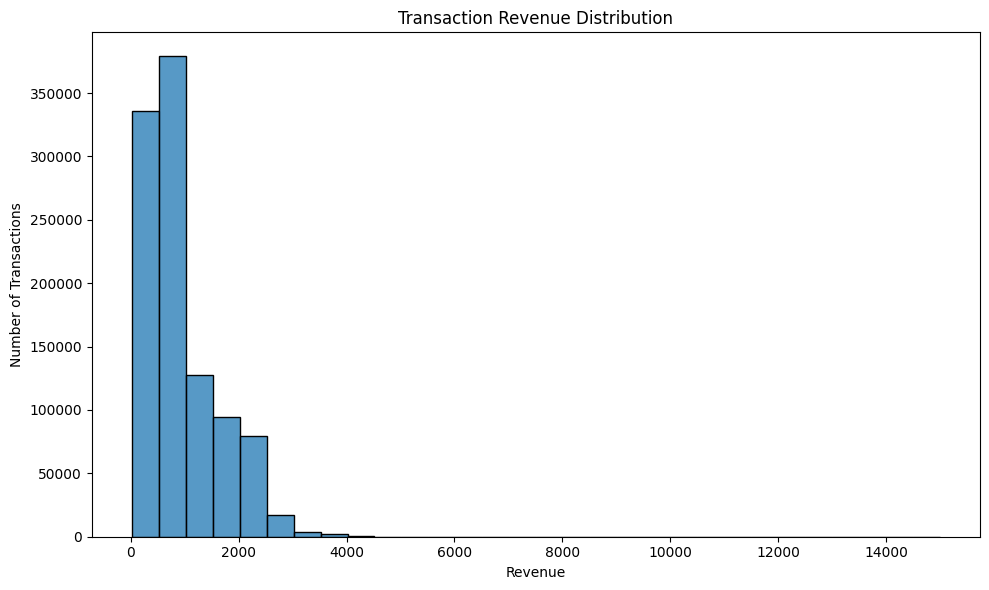

In [15]:
sales_products = sales.merge(
    products,
    on="product_id",
    how="left"
)

sales_products["revenue"] = (
    sales_products["quantity"] *
    sales_products["price"]
)

plt.figure(figsize=(10, 6))

sns.histplot(
    data=sales_products,
    x="revenue",
    kde=False,
    bins=30
)

plt.title("Transaction Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

Plot the distribution of quantity from sales.csv as a countplot rather than a histogram, and report what share of orders are single-unit

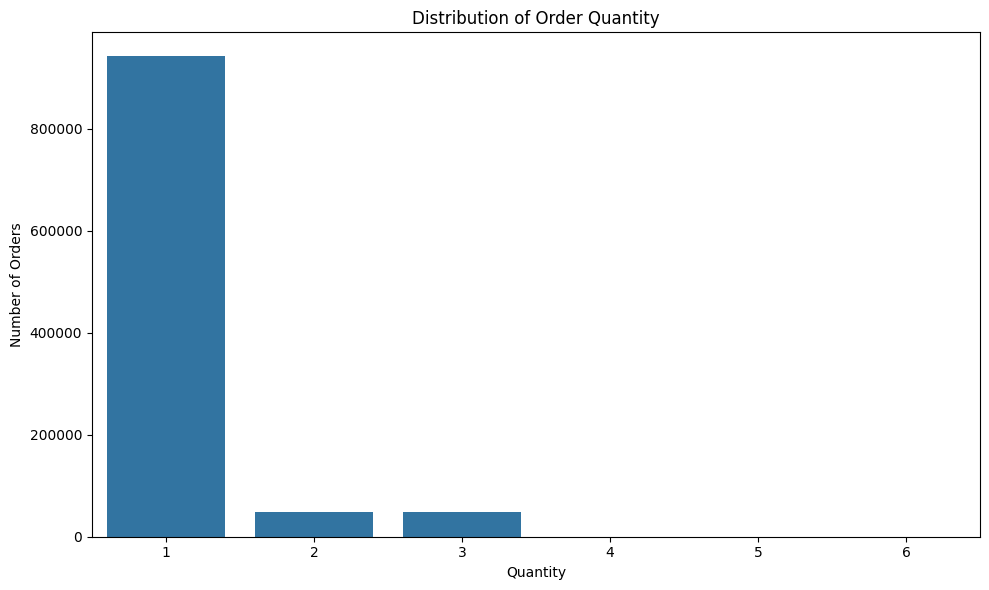

Single-unit orders share: 90.54%


In [17]:
# Quantity ka countplot

plt.figure(figsize=(10, 6))

sns.countplot(
    data=sales,
    x="quantity"
)

plt.title("Distribution of Order Quantity")
plt.xlabel("Quantity")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()


# Single-unit orders ka share

single_unit_orders = (sales["quantity"] == 1).sum()
total_orders = len(sales)

single_unit_share = (
    single_unit_orders / total_orders
) * 100

print(f"Single-unit orders share: {single_unit_share:.2f}%")

Plot the count of warranty claims per claim_status from warranty.csv, and explain whether a pie chart would be a better choice here

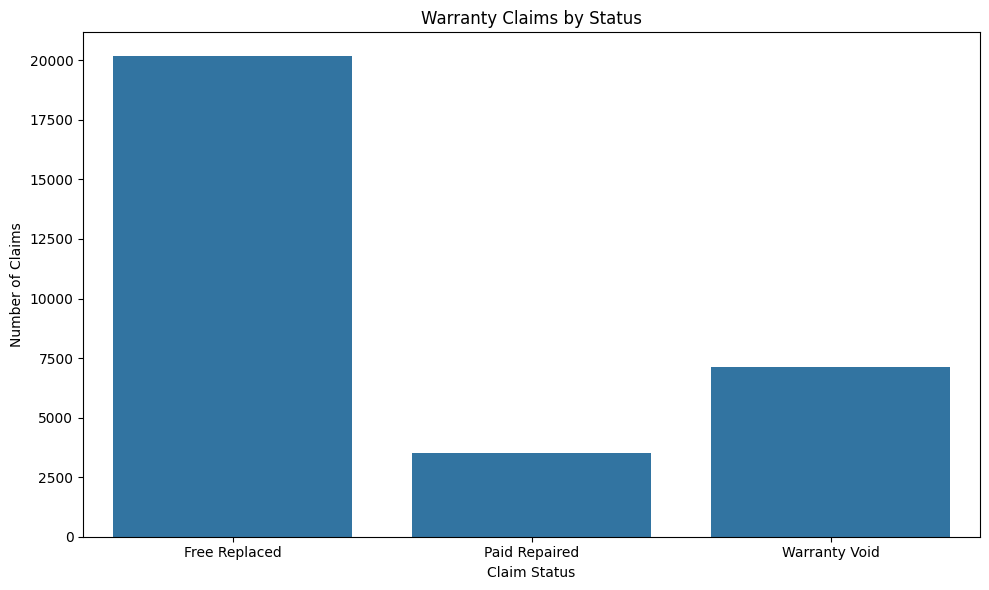

In [19]:
warranty = pd.read_csv("../../../Data/warranty.csv")

plt.figure(figsize=(10, 6))

sns.countplot(
    data=warranty,
    x="claim_status"
)

plt.title("Warranty Claims by Status")
plt.xlabel("Claim Status")
plt.ylabel("Number of Claims")

plt.tight_layout()
plt.show()

Combine the price, quantity, and claim_status distributions into a single diagnostic figure and flag anything operationally unusual

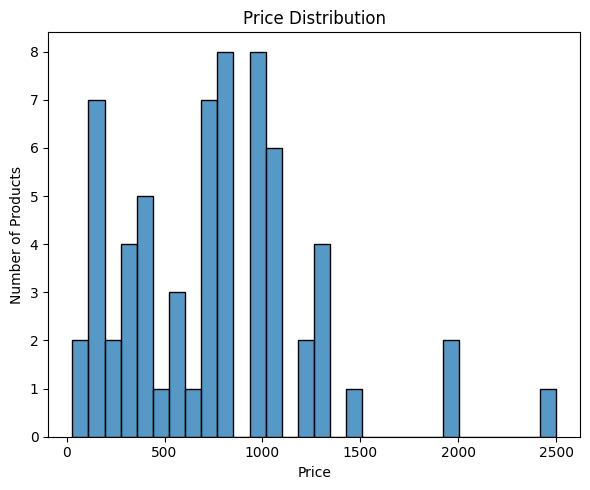

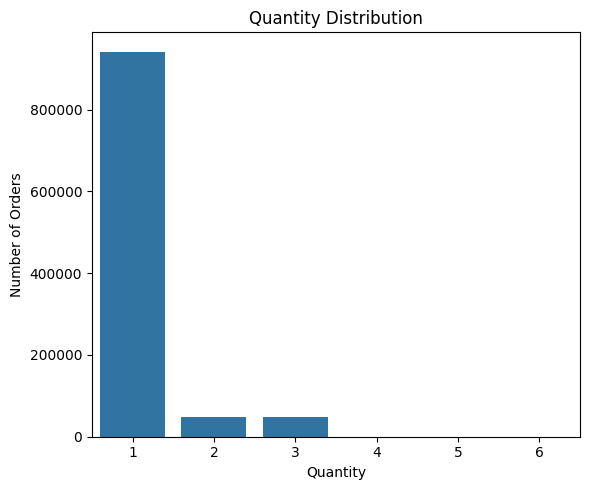

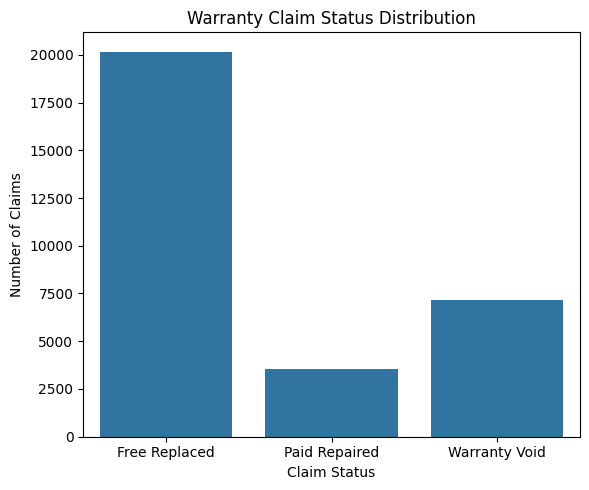

In [23]:
plt.figure(figsize=(6, 5))

sns.histplot(
    data=products,
    x="price",
    bins=30,
    kde=False
)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))

sns.countplot(
    data=sales,
    x="quantity"
)

plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 5))

sns.countplot(
    data=warranty,
    x="claim_status"
)

plt.title("Warranty Claim Status Distribution")
plt.xlabel("Claim Status")
plt.ylabel("Number of Claims")

plt.tight_layout()
plt.show()

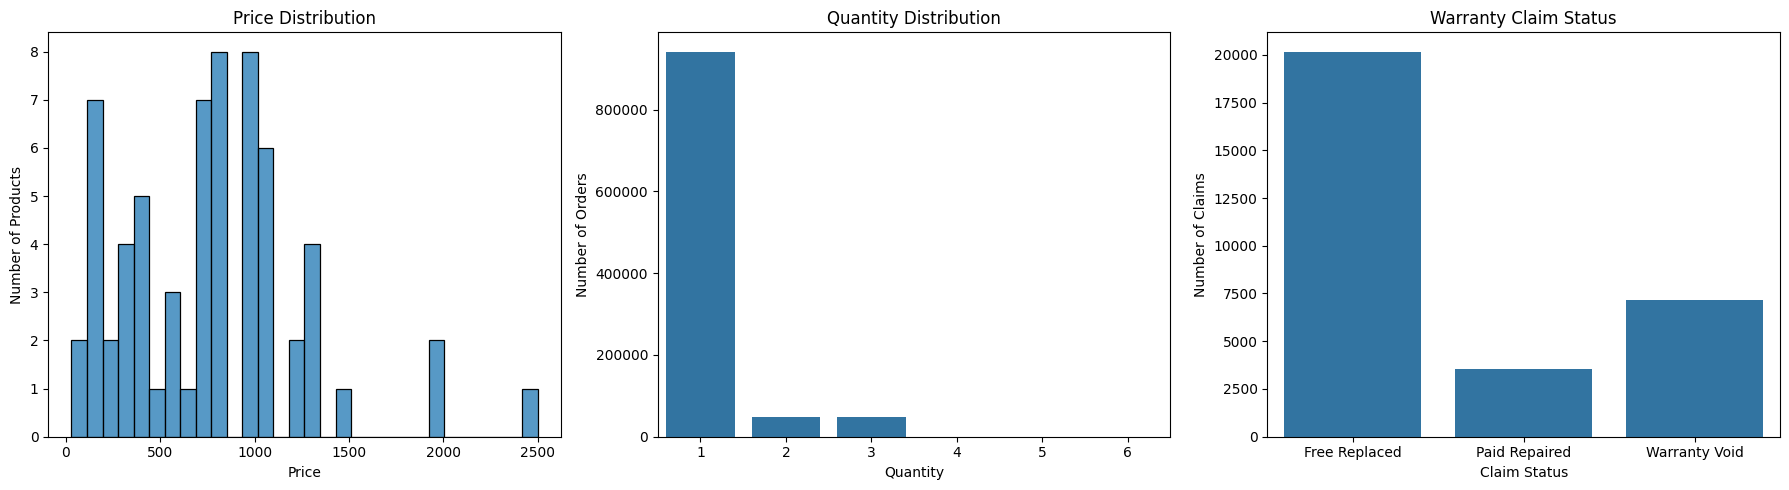

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Price
sns.histplot(
    data=products,
    x="price",
    bins=30,
    kde=False,
    ax=axes[0]
)
axes[0].set_title("Price Distribution")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Number of Products")


# 2. Quantity
sns.countplot(
    data=sales,
    x="quantity",
    ax=axes[1]
)
axes[1].set_title("Quantity Distribution")
axes[1].set_xlabel("Quantity")
axes[1].set_ylabel("Number of Orders")


# 3. Claim Status
sns.countplot(
    data=warranty,
    x="claim_status",
    ax=axes[2]
)
axes[2].set_title("Warranty Claim Status")
axes[2].set_xlabel("Claim Status")
axes[2].set_ylabel("Number of Claims")


plt.tight_layout()
plt.show()